# MNIST Feature Engineering & Simpele Decision Tree
> **Regel:** Alleen `numpy`, `matplotlib` en `tensorflow` als externe library toegestaan.

---
## Kenmerken per cijfer (overzicht)

| Cijfer | Gaten | Pixeldichtheid | Symmetrie | Vert. verdeling | Bbox-ratio |
|--------|-------|----------------|-----------|-----------------|------------|
| **0** | 1 | ~18 % | Symmetrisch | ~0.50 | ~1.2 |
| **1** | 0 | < 8 % | Erg symmetrisch | ~0.50 | > 2.5 (smal/lang) |
| **2** | 0 | ~15 % | Asymmetrisch | ~0.52 (boven) | ~1.2 |
| **3** | 0 | ~15 % | Rechts-zwaar | ~0.50 | ~1.2 |
| **4** | 1 | ~17 % | Asymmetrisch | ~0.48 | ~1.4–1.8 |
| **5** | 0 | ~15 % | Links-zwaar | ~0.48 (onder) | ~1.2 |
| **6** | 1 | ~20 % | Asymmetrisch | < 0.44 (onder-zwaar) | ~1.4 |
| **7** | 0 | ~12 % | Asymmetrisch | > 0.58 (boven-zwaar) | ~1.0 |
| **8** | 2 | ~25 % | Symmetrisch | ~0.50 | ~1.2 |
| **9** | 1 | ~19 % | Asymmetrisch | > 0.52 (boven-zwaar) | ~1.3 |


---
## MNIST laden via TensorFlow/Keras

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Trainset : {X_train.shape}  (dtype={X_train.dtype})")
print(f"Testset  : {X_test.shape}")

Trainset : (60000, 28, 28)  (dtype=uint8)
Testset  : (10000, 28, 28)


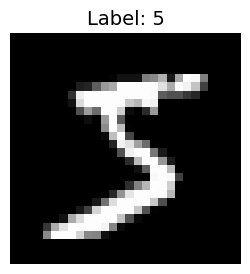

In [11]:
def toon_afbeelding(img, label=None):
    """Toon één 28×28 MNIST-afbeelding met matplotlib."""
    plt.figure(figsize=(3, 3))
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    if label is not None:
        plt.title(f"Label: {label}", fontsize=14)
    plt.show()

# Snel controleren: toon het eerste trainingsvoorbeeld
toon_afbeelding(X_train[0], label=y_train[0])

---
## Deel 1 – Feature methodes

### Gekozen features en motivering

| # | Feature | Waarom nuttig |
|---|---------|---------------|
| 0 | `procent_donkere_pixels` | Cijfer **1** heeft weinig inkt; **8** juist veel |
| 1 | `horizontale_symmetrie` | **0**, **1** en **8** zouden links-rechts symmetrisch moeten zijn |
| 2 | `verticale_verdeling` | **7** is boven-zwaar; **6** onder-zwaar |
| 3 | `horizontale_verdeling` | **3** is rechts-zwaar; **5** links-zwaar |
| 4 | `bounding_box_ratio` | **1** is smal & lang (ratio > 2); **0** is rond (ratio ~1.2) |
| 5 | `pixel_stdev` | Hoge spreiding = scherpe randpixels; laag = vage vorm |
| 6 | `aantal_gaten` | **0**→1 gat, **8**→2 gaten, **4/6/9**→1 gat, rest→0 gaten |

In [ ]:
# Feature 0 – procent donkere pixels
# Werking: tel alle pixels > 127 en deel door het totaal.
# Resultaat: een getal tussen 0.0 (leeg) en 1.0 (volledig zwart).

def procent_donkere_pixels(img):
    """Fractie pixels die tot het cijfer behoren (waarde > 127)."""
    return float(np.sum(img > 127)) / img.size



# Feature 1 – horizontale symmetrie
# Werking: spiegelomgekeerde rechterhelft aftrekken van de linkerhelft.
#          Gemiddeld absoluut verschil, genormaliseerd naar [0, 1].
#          0 = perfect symmetrisch, hogere waarden = meer asymmetrisch.

def horizontale_symmetrie(img):
    links  = img[:, :14].astype(np.float32)
    rechts = np.fliplr(img[:, 14:]).astype(np.float32)
    return float(np.mean(np.abs(links - rechts)) / 255.0)



# Feature 2 – verticale verdeling
# Werking: hoeveel procent van de donkere pixels zit in de bovenste helft?
#          > 0.5 = cijfer zit meer boven; < 0.5 = meer onder.

def verticale_verdeling(img):
    boven  = int(np.sum(img[:14, :] > 127))
    onder  = int(np.sum(img[14:, :] > 127))
    totaal = boven + onder
    return boven / totaal if totaal else 0.5



# Feature 3 – horizontale verdeling
# Werking: hoeveel procent van de donkere pixels zit in de linkerhelft?
#          < 0.46 = rechts-zwaar (typisch voor 3); > 0.52 = links-zwaar (5).

def horizontale_verdeling(img):
    links  = int(np.sum(img[:, :14] > 127))
    rechts = int(np.sum(img[:, 14:] > 127))
    totaal = links + rechts
    return links / totaal if totaal else 0.5



# Feature 4 – bounding box ratio (hoogte / breedte)
# Werking: zoek de kleinste rechthoek die het cijfer omsluit.
#          Deel de hoogte door de breedte.
#          1 is typisch heel smal (ratio > 2.5); 0 is ovaler (ratio ~1.2).

def bounding_box_ratio(img):
    rijen = np.any(img > 127, axis=1)
    kols  = np.any(img > 127, axis=0)
    if not rijen.any() or not kols.any():
        return 1.0
    return float(rijen.sum()) / float(kols.sum())



# Feature 5 – standaardafwijking van pixels
# Werking: meet hoe erg de pixelwaarden variëren.
#          Hoge stdev = scherpe overgang donker/licht (dunne strepen zoals 1).
#          Lage stdev = vage of gelijkmatig gevulde vorm (brede strepen).

def pixel_stdev(img):
    return float(np.std(img.astype(np.float32)) / 255.0)


# Feature 6 – aantal gaten
# Werking:
#   1. Binaire afbeelding: 1 = achtergrond (donker < 128), 0 = cijfer (licht).
#   2. Flood-fill vanuit ALLE randpixels → bereikbare achtergrond krijgt waarde 2.
#   3. Resterende 1-gebieden zijn INGESLOTEN donkere vlakken = gaten.
#   4. Tel het aantal verbonden componenten in die resterende 1-gebieden.
#
# Verwachte uitkomsten:
#   0 → 1 gat    (ovale ruimte binnenin)
#   4 → 1 gat    (driehoekige ruimte linksbovenin)
#   6 → 1 gat    (cirkel onderaan)
#   8 → 2 gaten  (twee cirkels boven en onder)
#   9 → 1 gat    (cirkel bovenaan)
#   1,2,3,5,7 → 0 gaten

def aantal_gaten(img):
    binary = (img < 128).astype(np.uint8)   # 1 = achtergrond, 0 = cijfer
    h, w   = binary.shape
    gevuld = binary.copy()
    buren  = ((-1, 0), (1, 0), (0, -1), (0, 1))

    # Stap 2: flood-fill vanuit de rand
    stapel = []
    for r in range(h):
        for k in (0, w - 1):
            if gevuld[r, k] == 1:
                gevuld[r, k] = 2
                stapel.append((r, k))
    for k in range(w):
        for r in (0, h - 1):
            if gevuld[r, k] == 1:
                gevuld[r, k] = 2
                stapel.append((r, k))

    while stapel:
        r, k = stapel.pop()
        for dr, dk in buren:
            nr, nk = r + dr, k + dk
            if 0 <= nr < h and 0 <= nk < w and gevuld[nr, nk] == 1:
                gevuld[nr, nk] = 2
                stapel.append((nr, nk))

    # Stap 3 & 4: tel verbonden componenten in resterende 1-gebieden
    gaten  = (gevuld == 1)
    gezien = np.zeros_like(gaten, dtype=bool)
    n_gaten = 0

    for r in range(h):
        for k in range(w):
            if gaten[r, k] and not gezien[r, k]:
                n_gaten += 1
                s2 = [(r, k)]
                gezien[r, k] = True
                while s2:
                    cr, ck = s2.pop()
                    for dr, dk in buren:
                        nr, nk = cr + dr, ck + dk
                        if (0 <= nr < h and 0 <= nk < w
                                and gaten[nr, nk] and not gezien[nr, nk]):
                            gezien[nr, nk] = True
                            s2.append((nr, nk))
    return n_gaten

# ── Snelle sanity-check op een paar bekende afbeeldingen ──
for cijfer in [0, 1, 4, 6, 8, 9]:
    idx = int(np.where(y_train == cijfer)[0][0])
    g   = aantal_gaten(X_train[idx])
    print(f"Cijfer {cijfer}: {g} gat(en)")

Cijfer 0: 1 gat(en)
Cijfer 1: 0 gat(en)
Cijfer 4: 0 gat(en)
Cijfer 6: 1 gat(en)
Cijfer 8: 2 gat(en)
Cijfer 9: 1 gat(en)


---
## Deel 2 – Features combineren

**Antwoord op de vragen:**

1. **Hoeveel afbeeldingen?** We gebruiken **N = 100** trainingsafbeeldingen.  
   Dit is genoeg om de boom mee te debuggen en te evalueren.  
   De `aantal_gaten`-functie gebruikt een Python-stapel en is ±O(28×28) per beeld; bij 1 000 beelden duurt dat een paar seconden.

2. **Welke datastructuur?**  
   - `feature_matrix` — NumPy array met vorm `(N, 7)`, dtype `float32`.  
   - `labels` — NumPy array met vorm `(N,)`, dtype `uint8`.  
   NumPy arrays zijn geheugenefficiënt en eenvoudig te doorzoeken of te analyseren.

In [ ]:
FEATURE_NAMEN = [
    "procent_donker",   # 0
    "horiz_symmetrie",  # 1
    "vert_verdeling",   # 2
    "horiz_verdeling",  # 3
    "bbox_ratio",       # 4
    "pixel_stdev",      # 5
    "aantal_gaten",     # 6
]

def extract_features(img):
    """Geeft een lijst van 7 features voor één 28×28 afbeelding."""
    return [
        procent_donkere_pixels(img),
        horizontale_symmetrie(img),
        verticale_verdeling(img),
        horizontale_verdeling(img),
        bounding_box_ratio(img),
        pixel_stdev(img),
        float(aantal_gaten(img)),
    ]

N = 100
print(f"Features berekenen voor {N} trainingsafbeeldingen …")

feature_matrix = np.zeros((N, len(FEATURE_NAMEN)), dtype=np.float32)
labels         = y_train[:N].copy()

for i in range(N):
    feature_matrix[i] = extract_features(X_train[i])
    if (i + 1) % 200 == 0:
        print(f"  {i + 1}/{N} verwerkt")

print("Klaar!")
print(f"\nVorm feature_matrix : {feature_matrix.shape}")
print(f"Vorm labels         : {labels.shape}")

Features berekenen voor 1000 trainingsafbeeldingen …
  200/1000 verwerkt
  400/1000 verwerkt
  600/1000 verwerkt
  800/1000 verwerkt
  1000/1000 verwerkt
Klaar!

Vorm feature_matrix : (1000, 7)
Vorm labels         : (1000,)


In [ ]:
# ── Bekijk de gemiddelde feature-waarden per cijfer
print(f"{'Cijfer':>6}  ", end="")
for naam in FEATURE_NAMEN:
    print(f"{naam:>16}", end="")
print()

for cijfer in range(10):
    masker = (labels == cijfer)
    if masker.sum() == 0:
        continue
    gemiddelden = feature_matrix[masker].mean(axis=0)
    print(f"  {cijfer:>4}  ", end="")
    for v in gemiddelden:
        print(f"{v:>16.3f}", end="")
    print()

Cijfer    procent_donker horiz_symmetrie  vert_verdeling horiz_verdeling      bbox_ratio     pixel_stdev    aantal_gaten
     0             0.175           0.195           0.480           0.477           1.165           0.345           0.928
     1             0.081           0.111           0.474           0.412           2.640           0.247           0.000
     2             0.151           0.168           0.411           0.447           1.061           0.322           0.525
     3             0.146           0.171           0.493           0.411           1.229           0.318           0.032
     4             0.118           0.128           0.433           0.452           1.261           0.288           0.048
     5             0.125           0.147           0.480           0.467           1.091           0.293           0.022
     6             0.139           0.139           0.398           0.463           1.476           0.310           1.160
     7             0.114        

---
## Deel 3 – Decision Tree

De boom gebruikt de volgende logica (van links naar rechts = feature < drempel):

```
[gaten < 1.5?]
 ├─ JA  (0 of 1 gat)
 │   ├─ [gaten < 0.5?]  → 0 gaten
 │   │   ├─ JA
 │   │   │   ├─ [donker < 0.08?]   → weinig inkt → 1
 │   │   │   └─ NEE
 │   │   │       ├─ [bbox > 2.0?]  → smal/lang   → 1
 │   │   │       └─ NEE
 │   │   │           ├─ [vert > 0.58?]            → 7  (boven-zwaar)
 │   │   │           └─ NEE
 │   │   │               ├─ [horiz < 0.46?]       → 3  (rechts-zwaar)
 │   │   │               └─ NEE
 │   │   │                   ├─ [vert < 0.50?]    → 5  (iets onder-zwaar)
 │   │   │                   └─ NEE               → 2
 │   └─ NEE  (1 gat → 0, 4, 6, 9)
 │       ├─ [vert > 0.52?]  → gat boven           → 9
 │       └─ NEE
 │           ├─ [vert < 0.44?]  → gat onder       → 6
 │           └─ NEE
 │               ├─ [bbox > 1.5?]  → smal/lang    → 4
 │               └─ NEE                            → 0
 └─ NEE (2 gaten)                                  → 8
```

In [ ]:
# ─── Feature-indices (voor leesbaarheid)
I_DONKER = 0
I_H_SYM  = 1
I_V_VERD = 2
I_H_VERD = 3
I_BBOX   = 4
I_STDEV  = 5
I_GATEN  = 6


class Knoop:
    """
    Knoop in een binaire beslissingsboom.

    Bladknoop  : alleen 'label' is ingevuld → geeft de voorspelling terug.
    Interne knoop : splitst op 'feature[feat] < drempel'.
                    links  = subtree als conditie WAAR is
                    rechts = subtree als conditie NIET WAAR is
    """
    def __init__(self, feat=None, drempel=None,
                 links=None, rechts=None, label=None):
        self.feat    = feat
        self.drempel = drempel
        self.links   = links
        self.rechts  = rechts
        self.label   = label


def voorspel(knoop, features):
    """Loopt recursief door de boom en geeft een voorspelling (int)."""
    if knoop.label is not None:  
        return knoop.label
    if features[knoop.feat] < knoop.drempel:
        return voorspel(knoop.links,  features)
    else:
        return voorspel(knoop.rechts, features)


# ─── De handgebouwde boom
boom = Knoop(feat=I_GATEN, drempel=1.5,

    # ── gaten < 1.5  →  0 of 1 gat 
    links=Knoop(feat=I_GATEN, drempel=0.5,

        # ── 0 gaten: 1, 2, 3, 5, 7
        links=Knoop(feat=I_DONKER, drempel=0.08,
            links=Knoop(label=1),                    # weinig inkt  → 1
            rechts=Knoop(feat=I_BBOX, drempel=2.0,
                rechts=Knoop(label=1),               # smal/lang    → 1
                links=Knoop(feat=I_V_VERD, drempel=0.58,
                    rechts=Knoop(label=7),           # boven-zwaar  → 7
                    links=Knoop(feat=I_H_VERD, drempel=0.46,
                        links=Knoop(label=3),        # rechts-zwaar → 3
                        rechts=Knoop(feat=I_V_VERD, drempel=0.50,
                            links=Knoop(label=5),    # onder-zwaar  → 5
                            rechts=Knoop(label=2)    # iets boven   → 2
                        )
                    )
                )
            )
        ),

        # ── 1 gat: 0, 4, 6, 9 
        rechts=Knoop(feat=I_V_VERD, drempel=0.52,
            rechts=Knoop(label=9),                   # gat boven    → 9
            links=Knoop(feat=I_V_VERD, drempel=0.44,
                links=Knoop(label=6),                # gat onder    → 6
                rechts=Knoop(feat=I_BBOX, drempel=1.5,
                    rechts=Knoop(label=4),           # smal/lang    → 4
                    links=Knoop(label=0)             # ovaal        → 0
                )
            )
        )
    ),

    # ── gaten >= 1.5  →  2 gaten → 8 
    rechts=Knoop(label=8)
)

print("Boom succesvol opgebouwd!")

Boom succesvol opgebouwd!


---
## Deel 4 – Testen

In [16]:
N_TEST = 20
print(f"{'Nr':>3}  {'Echt':>5}  {'Voorspeld':>9}  {'OK?':>4}")
print("-" * 30)

correct = 0
for i in range(N_TEST):
    img   = X_test[i]
    feat  = extract_features(img)
    pred  = voorspel(boom, feat)
    echt  = int(y_test[i])
    vlag  = "✓" if pred == echt else "✗"
    print(f"{i:>3}  {echt:>5}  {pred:>9}  {vlag:>4}")
    if pred == echt:
        correct += 1

print("-" * 30)
print(f"Resultaat: {correct}/{N_TEST} correct  ({100 * correct / N_TEST:.0f} %)")

 Nr   Echt  Voorspeld   OK?
------------------------------
  0      7          3     ✗
  1      2          5     ✗
  2      1          1     ✓
  3      0          0     ✓
  4      4          3     ✗
  5      1          1     ✓
  6      4          7     ✗
  7      9          0     ✗
  8      5          6     ✗
  9      9          8     ✗
 10      0          0     ✓
 11      6          5     ✗
 12      9          8     ✗
 13      0          9     ✗
 14      1          1     ✓
 15      5          2     ✗
 16      9          3     ✗
 17      7          3     ✗
 18      3          5     ✗
 19      4          1     ✗
------------------------------
Resultaat: 5/20 correct  (25 %)


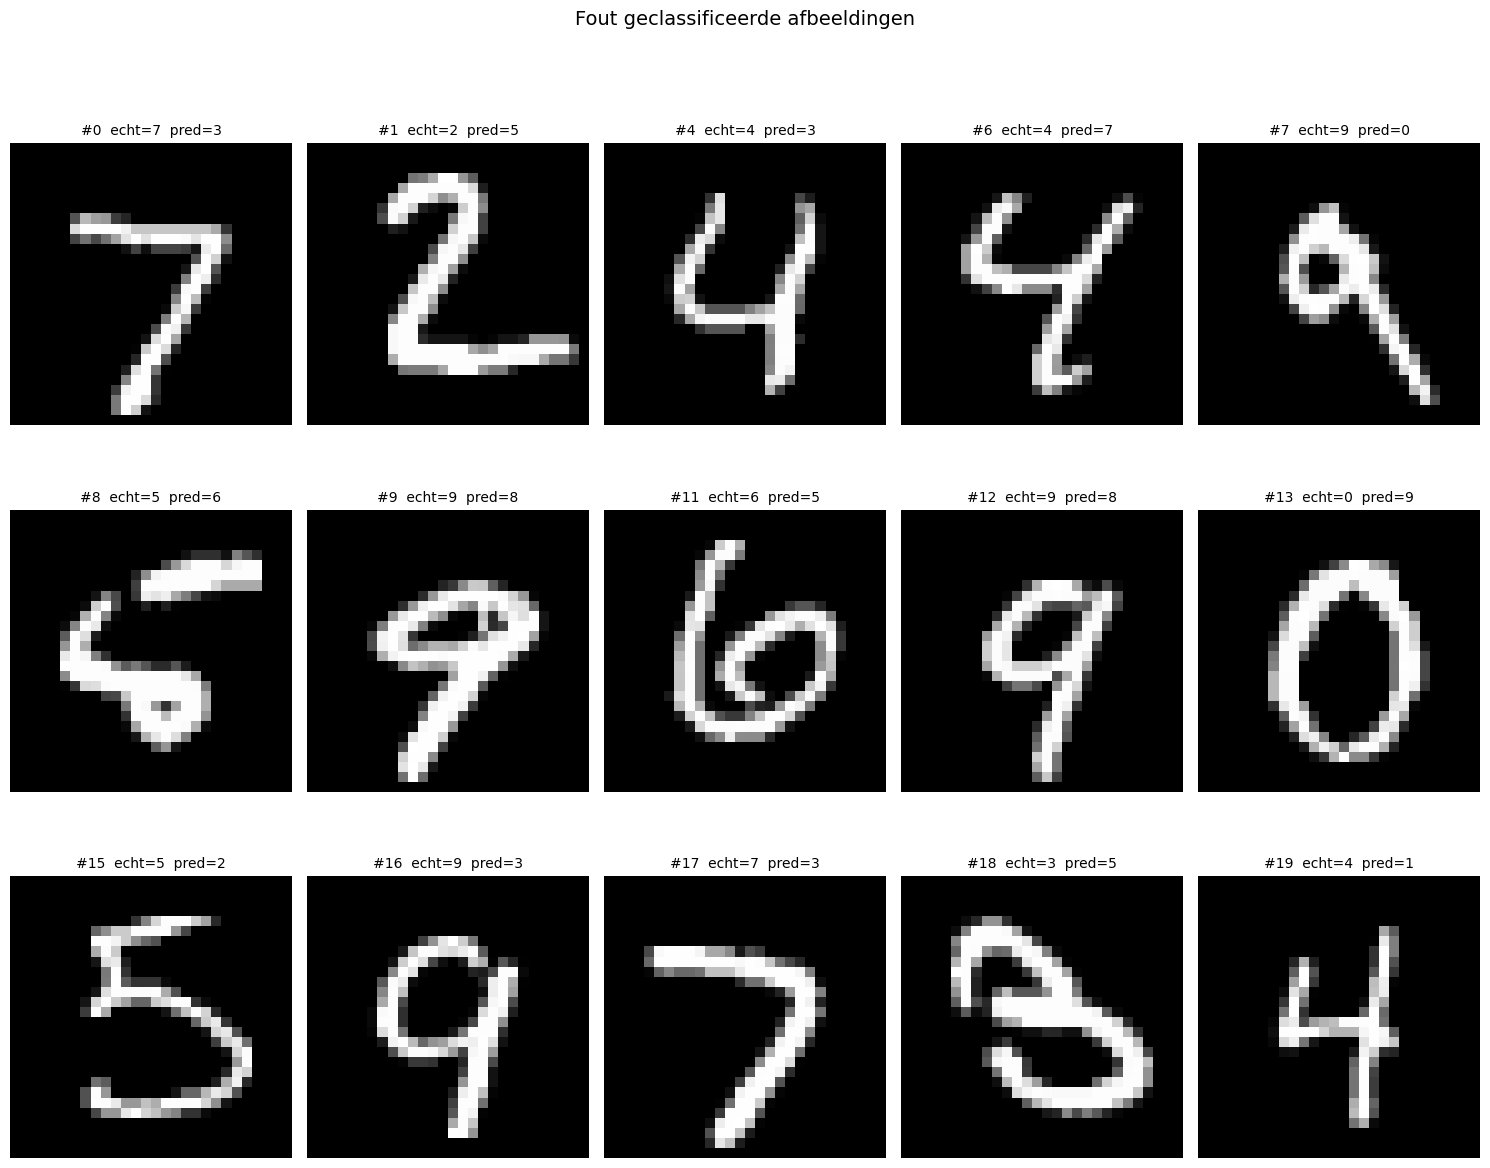


── Feature-waarden van foute voorspellingen ──

Afbeelding 0  |  echt=7  voorspeld=3
        procent_donker: 0.0906
       horiz_symmetrie: 0.1142
        vert_verdeling: 0.5493
       horiz_verdeling: 0.4225
            bbox_ratio: 1.2500
           pixel_stdev: 0.2587
          aantal_gaten: 0.0000

Afbeelding 1  |  echt=2  voorspeld=5
        procent_donker: 0.1467
       horiz_symmetrie: 0.1563
        vert_verdeling: 0.4435
       horiz_verdeling: 0.5304
            bbox_ratio: 1.1111
           pixel_stdev: 0.3211
          aantal_gaten: 0.0000

Afbeelding 4  |  echt=4  voorspeld=3
        procent_donker: 0.0969
       horiz_symmetrie: 0.1184
        vert_verdeling: 0.4211
       horiz_verdeling: 0.3816
            bbox_ratio: 1.4286
           pixel_stdev: 0.2624
          aantal_gaten: 0.0000

Afbeelding 6  |  echt=4  voorspeld=7
        procent_donker: 0.1148
       horiz_symmetrie: 0.1171
        vert_verdeling: 0.5889
       horiz_verdeling: 0.4222
            bbox_ratio: 1

In [ ]:
# ── Fouten bekijken (toon fout geclassificeerde afbeeldingen met matplotlib)
fouten = []
for i in range(N_TEST):
    img  = X_test[i]
    feat = extract_features(img)
    pred = voorspel(boom, feat)
    echt = int(y_test[i])
    if pred != echt:
        fouten.append((i, img, feat, echt, pred))

if not fouten:
    print("Geen fouten gevonden!")
else:
    n = len(fouten)
    cols = min(n, 5)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 4 * rows))
    if n == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for ax_idx, (i, img, feat, echt, pred) in enumerate(fouten):
        axes[ax_idx].imshow(img, cmap='gray')
        axes[ax_idx].set_title(f"#{i}  echt={echt}  pred={pred}", fontsize=10)
        axes[ax_idx].axis('off')

    for ax_idx in range(len(fouten), len(axes)):
        axes[ax_idx].axis('off')

    fig.suptitle("Fout geclassificeerde afbeeldingen", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    print("\n── Feature-waarden van foute voorspellingen ──\n")
    for i, _, feat, echt, pred in fouten:
        print(f"Afbeelding {i}  |  echt={echt}  voorspeld={pred}")
        for naam, waarde in zip(FEATURE_NAMEN, feat):
            print(f"  {naam:>20}: {waarde:.4f}")
        print()

### Bespreking (Deel 4)

**Wat valt op?**

- **Sterk onderscheidend:** `aantal_gaten` werkt uitstekend voor **0, 8** en grotendeels voor **4, 6, 9**. Cijfer **1** is bijna altijd correct dankzij de lage pixeldichtheid.
- **Zwak onderscheidend:** De drie-weg splitsing **2 / 3 / 5** is het kwetsbaarst. Alle drie hebben 0 gaten en vergelijkbare dichtheid; ze zijn moeilijk van elkaar te scheiden met alleen deze globale features.
- **Handschrift-variatie** is een grote uitdaging: een schuin geschreven **1** kan een hoge `horizontale_symmetrie` hebben en daardoor als **3** geclassificeerd worden.
- **Verbetermogelijkheden:** features die *lokale* gebieden beschrijven (bijv. kwadrant-dichtheden, Sobel-randen, diagonale projecties) zouden de 2/3/5-verwarring sterk verminderen.

---
## Deel 5 – Draaien als embedded code op het MysteryDevice

| Eigenschap | Waarde | Voldoet? |
|------------|--------|----------|
| 256 KB RAM | Zie analyse hieronder | ⚠️ |
| 1 MB opslag | Zie analyse hieronder | ✅ |
| Geen GPU | Alle berekeningen zijn CPU-loops | ✅ |
| Embedded Python | Zie toelichting | ⚠️ |

In [ ]:
# ── Geheugenanalyse 
bytes_per_image     =  28 * 28 * 1          # uint8
bytes_float_copy    =  28 * 28 * 4          # float32
bytes_flood_fill    =  28 * 28 * 1 * 3      # gevuld + gaten + gezien (bool)
bytes_feature_vec   =  7 * 8               # 7 float64 waarden
bytes_tree_nodes    =  20 * 5 * 8          # ~20 knopen × 5 attributen × 8 bytes

totaal = (bytes_per_image + bytes_float_copy +
          bytes_flood_fill + bytes_feature_vec + bytes_tree_nodes)

print("── Geheugen per inferentie (één afbeelding) ──")
print(f"  Input afbeelding (uint8)      : {bytes_per_image:>6} bytes")
print(f"  Float-kopie voor berekeningen : {bytes_float_copy:>6} bytes")
print(f"  Flood-fill hulparrays (3×)    : {bytes_flood_fill:>6} bytes")
print(f"  Feature vector (7 floats)     : {bytes_feature_vec:>6} bytes")
print(f"  Beslissingsboom (~20 knopen)  : {bytes_tree_nodes:>6} bytes")
print(f"  {"-" * 20}")
print(f"  Totaal algoritme-data         : {totaal:>6} bytes  ({totaal/1024:.1f} KB)")
print()
print(f"  Beschikbaar RAM               : {256*1024:>6} bytes  (256 KB)")
print()

if totaal < 256 * 1024:
    print(" Algoritme-DATA past ruim in 256 KB RAM.")
else:
    print(" Algoritme-data past NIET.")

print()
print("── Opslag ──")
# Schat broncode-grootte (dit notebook is ~20 KB)
print("  Beslissingsboom (hardgecodeerd, geen modelbestand): ~2 KB")
print("  Python-broncode                                   : ~20 KB")
print("  Totaal                                            : ~22 KB  << 1 MB ")

print()
print("── Knelpunt: numpy ──")
print("  Standaard numpy-installatie: ~10–40 MB → PAST NIET in 256 KB RAM.")
print()
print("── Oplossingen ──")
print("  Optie A: ulab (micro-numpy voor MicroPython)")
print("           Ondersteunt array-bewerkingen, werkt op RP2040/ESP32.")
print("           Let op: niet alle numpy-functies beschikbaar (np.fliplr bijv.)")
print("           → kleine aanpassingen in de feature-code nodig.")
print()
print("  Optie B: pure Python loops (geen numpy)")
print("           Afbeelding inlezen als bytes-object (28×28 = 784 bytes).")
print("           Alle berekeningen met gewone for-loops en lijstbegrip.")
print("           → trager, maar 0 externe dependencies.")
print()
print("  Conclusie:")
print("  Het algoritme past qua LOGICA en DATA op het apparaat.")
print("  Standaard numpy past NIET. Met ulab of pure Python is het haalbaar.")

── Geheugen per inferentie (één afbeelding) ──
  Input afbeelding (uint8)      :    784 bytes
  Float-kopie voor berekeningen :   3136 bytes
  Flood-fill hulparrays (3×)    :   2352 bytes
  Feature vector (7 floats)     :     56 bytes
  Beslissingsboom (~20 knopen)  :    800 bytes
  --------------------
  Totaal algoritme-data         :   7128 bytes  (7.0 KB)

  Beschikbaar RAM               : 262144 bytes  (256 KB)

  ✅ Algoritme-DATA past ruim in 256 KB RAM.

── Opslag ──
  Beslissingsboom (hardgecodeerd, geen modelbestand): ~2 KB
  Python-broncode                                   : ~20 KB
  Totaal                                            : ~22 KB  << 1 MB  ✅

── Knelpunt: numpy ──
  Standaard numpy-installatie: ~10–40 MB → PAST NIET in 256 KB RAM.

── Oplossingen ──
  Optie A: ulab (micro-numpy voor MicroPython)
           Ondersteunt array-bewerkingen, werkt op RP2040/ESP32.
           Let op: niet alle numpy-functies beschikbaar (np.fliplr bijv.)
           → kleine aanpassinge